# <center> Heart Disease Visualization

## Features Info:
HeartDisease: Respondents that have ever reported having coronary heart disease (CHD) or myocardial infarction (MI)

BMI: Body Mass Index (BMI)

Smoking: Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes]

AlcoholDrinking: Heavy drinkers (adult men having more than 14 drinks per week and adult women having more than 7 drinks per week

Stroke: (Ever told) (you had) a stroke?

PhysicalHealth: Now thinking about your physical health, which includes physical illness and injury, for how many days during the past 30 days was your physical health not good? (0-30 days)

MentalHealth: Thinking about your mental health, for how many days during the past 30 days was your mental health not good? (0-30 days)

DiffWalking: Do you have serious difficulty walking or climbing stairs? Sex: Are you male or female? Female,Male

Key Indicators of Heart Disease 2020 annual CDC survey data of 400k adults related to their health status

## Importing Packages

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # Visualization
import seaborn as sns # Visualization
import missingno as msno 
colors = ['#B90276','#50237F', '#005691', '#008ECF','#E20015', '#00A8B0', '#78BE20', '#006249', '#525F6B']

sns.set_palette(sns.color_palette(colors))

### Loading Data

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/h221710306039/heartattack/main/DATA.csv')
df = pd.DataFrame(df)
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


### Below We can see that Features are mix of category and Numeric

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

### Lets check summary of Numerical features
Below we can see the count, mean, standard deviation, max etc.

In [4]:
df.describe().T.style.set_properties(**{'background-color': 'grey','color': 'white','border-color': 'white'})

,count,mean,std,min,25%,50%,75%,max
BMI,319795.000000,28.325399,6.356100,12.020000,24.030000,27.340000,31.420000,94.850000
PhysicalHealth,319795.000000,3.371710,7.950850,0.000000,0.000000,0.000000,2.000000,30.000000
MentalHealth,319795.000000,3.898366,7.955235,0.000000,0.000000,0.000000,3.000000,30.000000
SleepTime,319795.000000,7.097075,1.436007,1.000000,6.000000,7.000000,8.000000,24.000000


### Lets have a look on the Unique count of each column

In [5]:
df.nunique()

HeartDisease           2
BMI                 3604
Smoking                2
AlcoholDrinking        2
Stroke                 2
PhysicalHealth        31
MentalHealth          31
DiffWalking            2
Sex                    2
AgeCategory           13
Race                   6
Diabetic               4
PhysicalActivity       2
GenHealth              5
SleepTime             24
Asthma                 2
KidneyDisease          2
SkinCancer             2
dtype: int64

### Let See what are the Unique values in the column

In [6]:
for col in df.columns:
    print(col, '\n', df[col].unique(), '\n')

HeartDisease 
 ['No' 'Yes'] 

BMI 
 [16.6  20.34 26.58 ... 62.42 51.46 46.56] 

Smoking 
 ['Yes' 'No'] 

AlcoholDrinking 
 ['No' 'Yes'] 

Stroke 
 ['No' 'Yes'] 

PhysicalHealth 
 [ 3.  0. 20. 28.  6. 15.  5. 30.  7.  1.  2. 21.  4. 10. 14. 18.  8. 25.
 16. 29. 27. 17. 24. 12. 23. 26. 22. 19.  9. 13. 11.] 

MentalHealth 
 [30.  0.  2.  5. 15.  8.  4.  3. 10. 14. 20.  1.  7. 24.  9. 28. 16. 12.
  6. 25. 17. 18. 21. 29. 22. 13. 23. 27. 26. 11. 19.] 

DiffWalking 
 ['No' 'Yes'] 

Sex 
 ['Female' 'Male'] 

AgeCategory 
 ['55-59' '80 or older' '65-69' '75-79' '40-44' '70-74' '60-64' '50-54'
 '45-49' '18-24' '35-39' '30-34' '25-29'] 

Race 
 ['White' 'Black' 'Asian' 'American Indian/Alaskan Native' 'Other'
 'Hispanic'] 

Diabetic 
 ['Yes' 'No' 'No, borderline diabetes' 'Yes (during pregnancy)'] 

PhysicalActivity 
 ['Yes' 'No'] 

GenHealth 
 ['Very good' 'Fair' 'Good' 'Poor' 'Excellent'] 

SleepTime 
 [ 5.  7.  8.  6. 12.  4.  9. 10. 15.  3.  2.  1. 16. 18. 14. 20. 11. 13.
 17. 24. 19. 21. 22

### No Missing Data
If there would be missing data ther would be whiter spots on the location

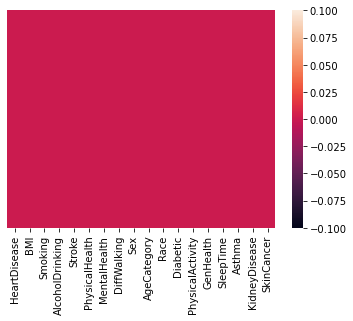

In [7]:
ax=sns.heatmap(df.isnull(),yticklabels=False)

## Correlation Plot
From the Below chart we can observe that Physical Health and Mental Health has High Correlation.

<AxesSubplot:>

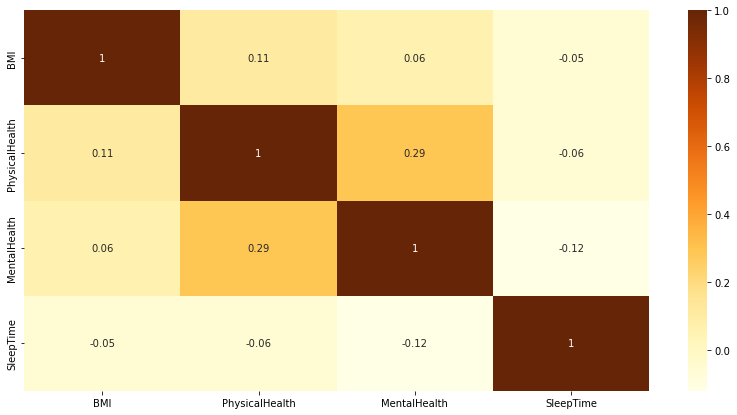

In [8]:
correlation = df.corr().round(2)
plt.figure(figsize = (14,7))
sns.heatmap(correlation, annot = True, cmap = 'YlOrBr')

### Number of Patients with heart Disease
As we can see that Data is Highly Imbalanced

<AxesSubplot:xlabel='HeartDisease', ylabel='count'>

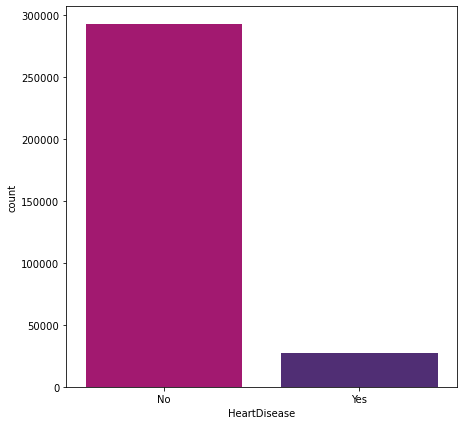

In [9]:
plt.figure(figsize=(7,7))
sns.countplot(data=df,x="HeartDisease")

### Percentage of people with heart disease
Below we can see that 8.6% people shows heart disease 

Text(0.5, 1.0, 'Percentage of people with heart disease')

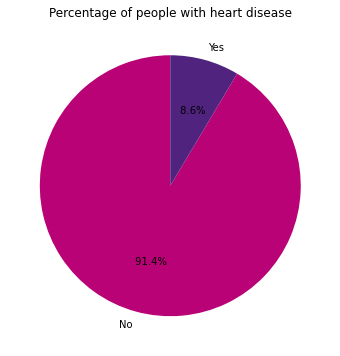

In [10]:
fig,ax=plt.subplots(figsize=(6,6))
plt.pie(x=df["HeartDisease"].value_counts(),labels=df["HeartDisease"].unique(),
        autopct="% 1.1f%%",startangle=90)
plt.title("Percentage of people with heart disease")

### From the Below Bell curve we can observe that max population of BMI ranges from 22-31

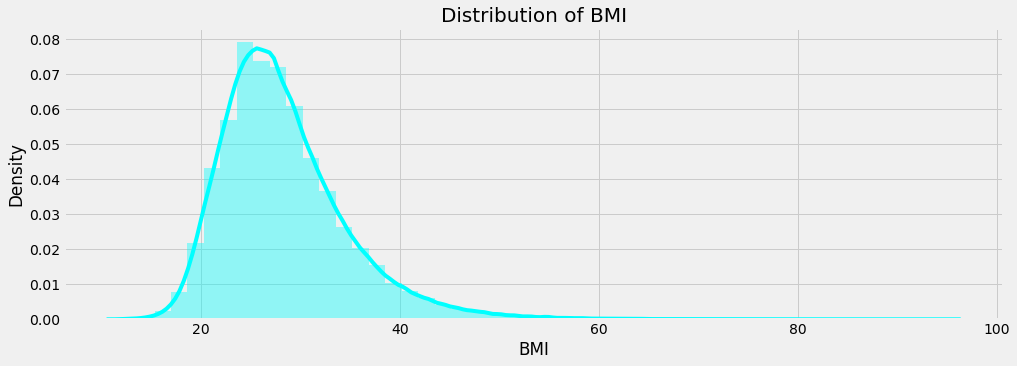

In [11]:
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 5)
sns.distplot(df['BMI'], color = 'cyan')
plt.title('Distribution of BMI', fontsize = 20)
plt.show()

### Below we can observe that 58.8% of people are Smokers in the data

Text(0.5, 1.0, 'Percentage of Smoking people')

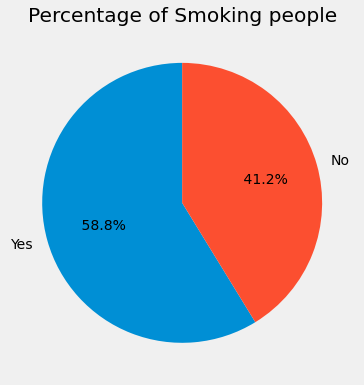

In [12]:
fig,ax=plt.subplots(figsize=(6,6))
plt.pie(x=df["Smoking"].value_counts(),labels=df["Smoking"].unique(),
        autopct="% 1.1f%%",startangle=90)
plt.title("Percentage of Smoking people")

### Below we can observe that 58.8% of people are Alcoholics in the data

Text(0.5, 1.0, 'Percentage of alcohol-heavy drinkers')

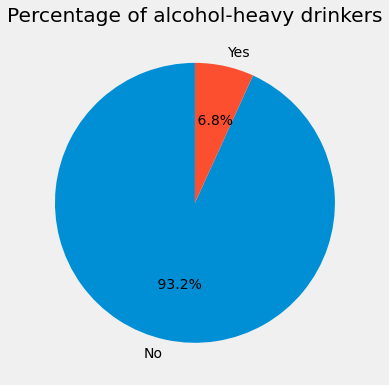

In [13]:
fig,ax=plt.subplots(figsize=(6,6))
plt.pie(x=df["AlcoholDrinking"].value_counts(),labels=df["AlcoholDrinking"].unique(),
        autopct="% 1.1f%%",startangle=90)
plt.title("Percentage of alcohol-heavy drinkers")

### Below we can see tha People who sleeps 7-8 hrs has good Physical Health

<AxesSubplot:xlabel='SleepTime', ylabel='PhysicalHealth'>

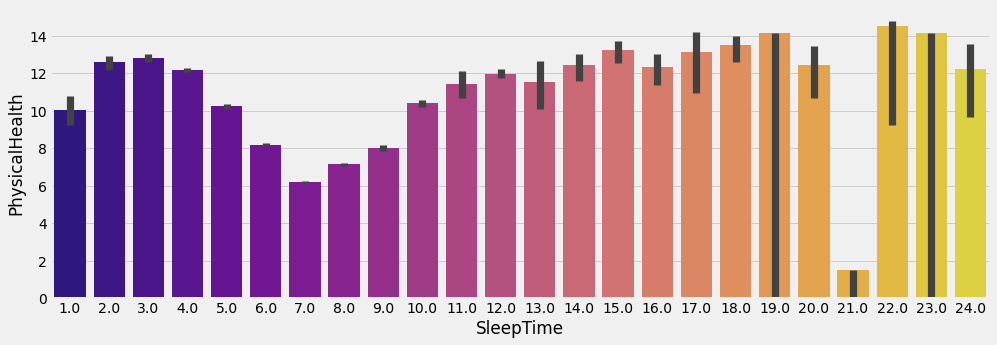

In [14]:
# change the estimator from mean to standard deviation
sns.barplot(x ='SleepTime', y ='PhysicalHealth', data = df,
            palette ='plasma', estimator = np.std)

### Data is equally Proportionate for Male and Female

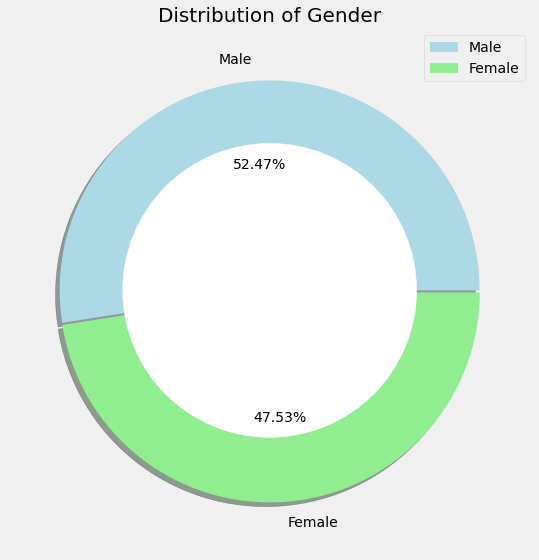

In [15]:
size = df['Sex'].value_counts()
colors = ['lightblue', 'lightgreen']
labels = "Male", "Female"
explode = [0, 0.01]

my_circle = plt.Circle((0, 0), 0.7, color = 'white')

plt.rcParams['figure.figsize'] = (9, 9)
plt.pie(size, colors = colors, labels = labels, shadow = True, explode = explode, autopct = '%.2f%%')
plt.title('Distribution of Gender', fontsize = 20)
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.legend()
plt.show()

### Below we can see that percentage of General Health of the people in the data

Text(0.5, 1.0, 'GenHealth')

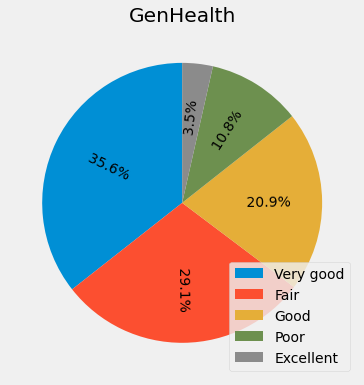

In [16]:
fig,ax=plt.subplots(figsize=(6,6))
patches, labels, pct_texts=plt.pie(x=df["GenHealth"].value_counts(),
        autopct="% 1.1f%%",
        startangle=90,rotatelabels = 270)
for label, pct_text in zip(labels, pct_texts):
    pct_text.set_rotation(label.get_rotation())
plt.legend(df["GenHealth"].unique(), loc="lower right")

plt.title("GenHealth")

### The majority of heart disease patients had bad physical health.

<AxesSubplot:xlabel='HeartDisease', ylabel='PhysicalHealth'>

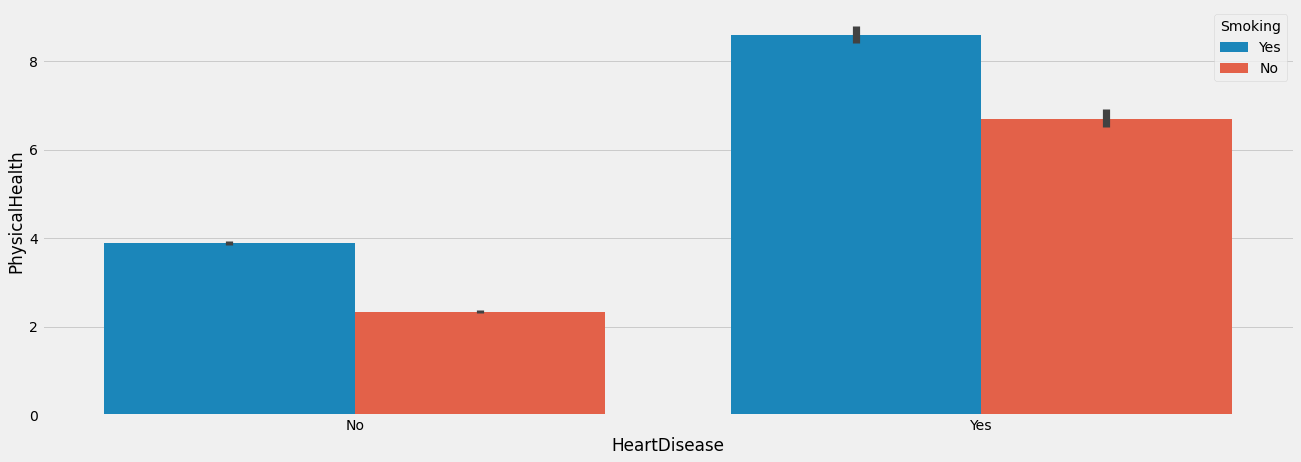

In [17]:
plt.figure(figsize=(20,7))
sns.barplot(data=df,x="HeartDisease",y="PhysicalHealth",hue="Smoking")

### We can see that people who are 60 or more are more likely to get the Heart Disease

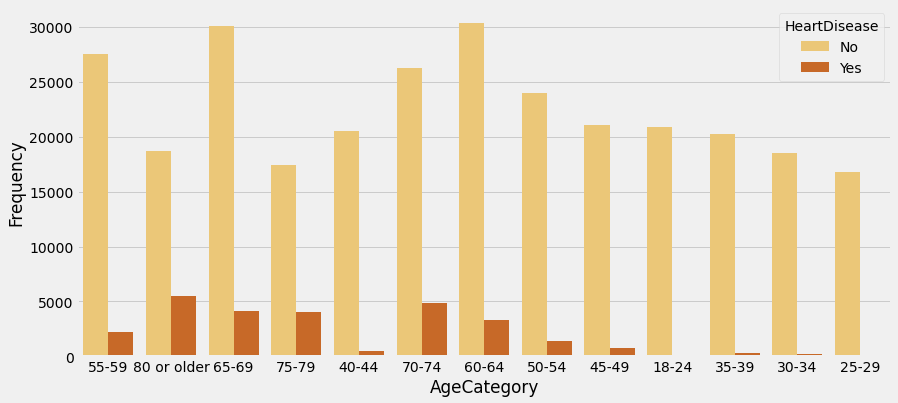

In [18]:
plt.figure(figsize = (13,6))
sns.countplot(x = df['AgeCategory'], hue = 'HeartDisease', data = df, palette = 'YlOrBr')
fig.suptitle("Distribution of Cases with Yes/No hartdisease according to AgeCategory")
plt.xlabel('AgeCategory')
plt.ylabel('Frequency')
plt.show()

### comparison of Heart Disease with Skin Cancer

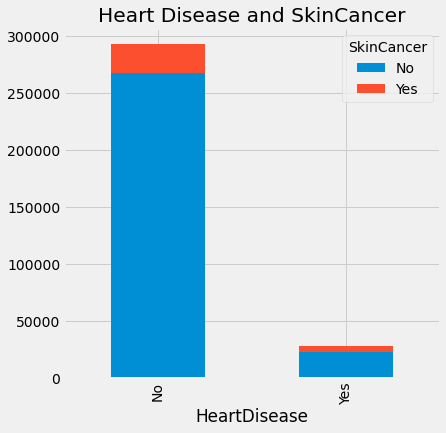

In [19]:
H_skin=pd.DataFrame(pd.crosstab(df["HeartDisease"],df["SkinCancer"])).reset_index()
ax=H_skin.plot(x="HeartDisease",kind='bar', stacked=True,
        title='Heart Disease and SkinCancer',figsize=(6,6))

### comparison of Heart Disease with Kidney Disease

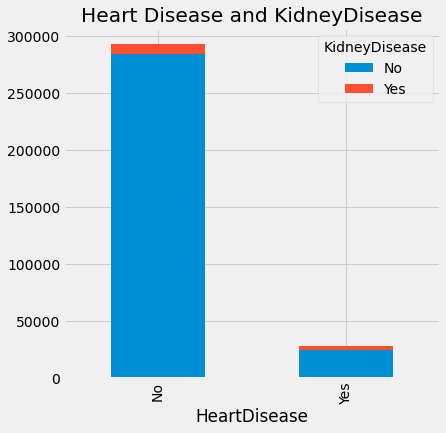

In [20]:
H_kid=pd.DataFrame(pd.crosstab(df["HeartDisease"],df["KidneyDisease"])).reset_index()
ax=H_kid.plot(x="HeartDisease",kind='bar', stacked=True,
        title='Heart Disease and KidneyDisease',figsize=(6,6))

### comparison of Heart Disease with Asthma

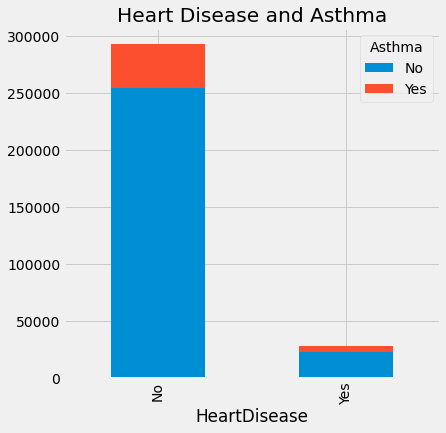

In [21]:
H_asthma=pd.DataFrame(pd.crosstab(df["HeartDisease"],df["Asthma"])).reset_index()
ax=H_asthma.plot(x="HeartDisease",kind='bar', stacked=True,
        title='Heart Disease and Asthma',figsize=(6,6))

### Comparison of Heart Disease with Sleep Time

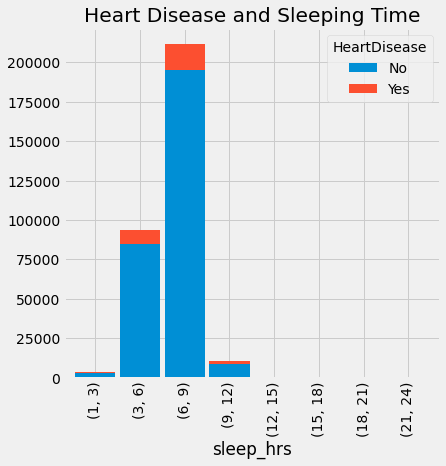

In [22]:
bins = 8
edges = np.linspace(df.SleepTime.min(), df.SleepTime.max(), bins+1).astype(int)
labels = [f'({edges[i]}, {edges[i+1]})' for i in range(bins)]
Sleep_Heart=df.copy()
Sleep_Heart["sleep_hrs"]=pd.cut(Sleep_Heart.SleepTime,bins=bins,labels=labels)
sleep_r=pd.crosstab(Sleep_Heart["sleep_hrs"],Sleep_Heart["HeartDisease"]).reset_index()
ax=sleep_r.plot(x="sleep_hrs",kind='bar', stacked=True,
        title='Heart Disease and Sleeping Time',figsize=(6,6),width=0.9)

### comparison of Heart Disease with Physical Activity

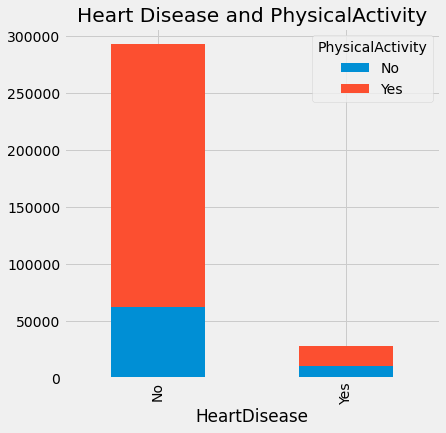

In [23]:
H_physical=pd.DataFrame(pd.crosstab(df["HeartDisease"],df["PhysicalActivity"])).reset_index()
ax=H_physical.plot(x="HeartDisease",kind='bar', stacked=True,
        title='Heart Disease and PhysicalActivity',figsize=(6,6))

### comparison of Heart Disease with Sex

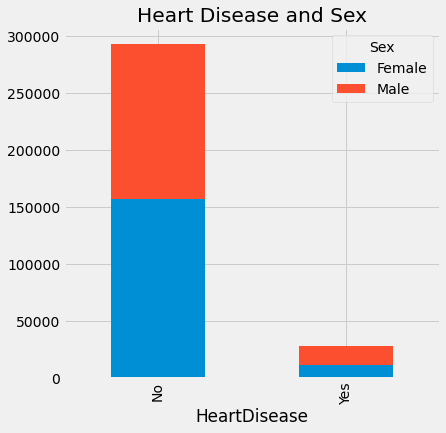

In [24]:
H_sex=pd.DataFrame(pd.crosstab(df["HeartDisease"],df["Sex"])).reset_index()
ax=H_sex.plot(x="HeartDisease",kind='bar', stacked=True,
        title='Heart Disease and Sex',figsize=(6,6))

## Finally We can see the comparison with Smokers

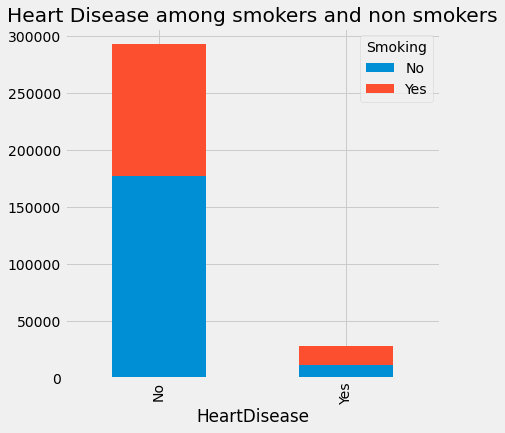

In [25]:
H_S=pd.DataFrame(pd.crosstab(df["HeartDisease"],df["Smoking"])).reset_index()
ax=H_S.plot(x="HeartDisease",kind='bar', stacked=True,
        title='Heart Disease among smokers and non smokers',figsize=(6,6))

## Conclusion
The majority of our questioned individuals did not have a heart disease concern, as evidenced by the data and histograms/pi charts shown above. 90.4% Furthermore, almost 41% have smoked at some point in their life. Age was evenly distributed, however race was not, since the majority of the participants were white. Furthermore, a history of diabetic illness was discovered in about 16% of the participants, among other difficulties indicated as General Health problems by more than half of those surveyed. (Examples include walking difficulties, kidney illness, and skin cancer.)

The correlation heatmap below illustrates how each of these diverged numerical metrics correlates with our goal feature in general.

As demonstrated in the correlation heatmap, general and physical health, walking difficulty, and past strokes and diabetes concerns appear to have the most impact on heart disease.